## Описание задания:
В задании нужно решить задачу регрессии. В качестве датасета необходимо взять данные о недвижимости Калифорнии из библиотеки https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html.
Целевая переменная – MedHouseVal. Прочитать информацию о признаках датасета можно, выполнив следующий код – print(fetch_california_housing().DESCR). На полученных данных построить модель регрессии и дерево решений.

Этапы работы:
- Получите данные и загрузите их в рабочую среду.
- Проведите первичный анализ.
- - a.Проверьте данные на пропуски. Удалите в случае обнаружения.
- - b.*Нормализуйте один из признаков.
- Разделите выборку на обучающее и тестовое подмножества. 80% данных оставить на обучающее множество, 20% - на тестовое.
- Обучите модель регрессии на обучающем множестве. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
- Для тестового множества предскажите целевую переменную и сравните с истинным значением, посчитав точность предсказания модели. Для этого используйте встроенную функцию score.
- Обучите дерево решений на обучающем множестве. https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html
- - a. Повторите п. 5 для полученной модели.
- - b. Визуализируйте часть дерева решений. Убедитесь, что график получился читабельным. Посмотрите примеры визуализации по ссылке. https://mljar.com/blog/visualize-decision-tree/
- Оптимизируйте глубину дерева (max_depth).
- - *Оптимизируйте ещё один параметр модели на выбор.
- - a. Повторите п. 5 для полученной модели.
- Сформулируйте выводы по проделанной работе.
- - a. Сравните точность двух моделей.
- - b. Напишите свое мнение, для каких задач предпочтительнее использовать обученные в работе модели? Какие у них есть плюсы и минусы?

Для получения зачета по этому домашнему заданию, должно быть как минимум реализовано обучение двух моделей, выведена их точность, оптимизирован один параметр дерева решений.


In [ ]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn import tree
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [ ]:
data = fetch_california_housing()
#print(fetch_california_housing().DESCR)

In [ ]:
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [ ]:
x = pd.DataFrame(data['data'], columns=data['feature_names'])
y = pd.Series(data['target'])
x.sample(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
11620,6.9830,21.0,7.477064,0.998471,2295.0,3.509174,33.84,-118.05
5867,5.1814,46.0,5.681356,1.091525,846.0,2.867797,34.19,-118.36
20058,1.5069,32.0,4.145833,1.020833,1282.0,3.815476,35.88,-119.27


In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [ ]:
x.isna().mean()

,0
MedInc,0.0
HouseAge,0.0
AveRooms,0.0
AveBedrms,0.0
Population,0.0
AveOccup,0.0
Latitude,0.0
Longitude,0.0


In [ ]:
y.head()

,0
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=777)
model = make_pipeline(StandardScaler(), LinearRegression())
model.fit(x_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearregression', LinearRegression())])

In [ ]:
model.score(x_train, y_train), model.score(x_test, y_test)
# результат не очень хороший

(0.6110124187808987, 0.5827784121245208)

In [ ]:
trees = DecisionTreeRegressor(random_state=123)
trees.fit(x_train, y_train)

DecisionTreeRegressor(random_state=123)

In [ ]:
trees.score(x_train, y_train), trees.score(x_test, y_test)
# явное переобучение

(1.0, 0.6303800841974734)

In [ ]:
trees1 = DecisionTreeRegressor(max_depth=5, min_samples_leaf=3, random_state=789)
trees1.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=5, min_samples_leaf=3, random_state=789)

In [ ]:
trees1.score(x_train, y_train), trees1.score(x_test, y_test)
# результат чуть лучше, но нет переобучения

(0.6313628280763435, 0.6034614689786502)

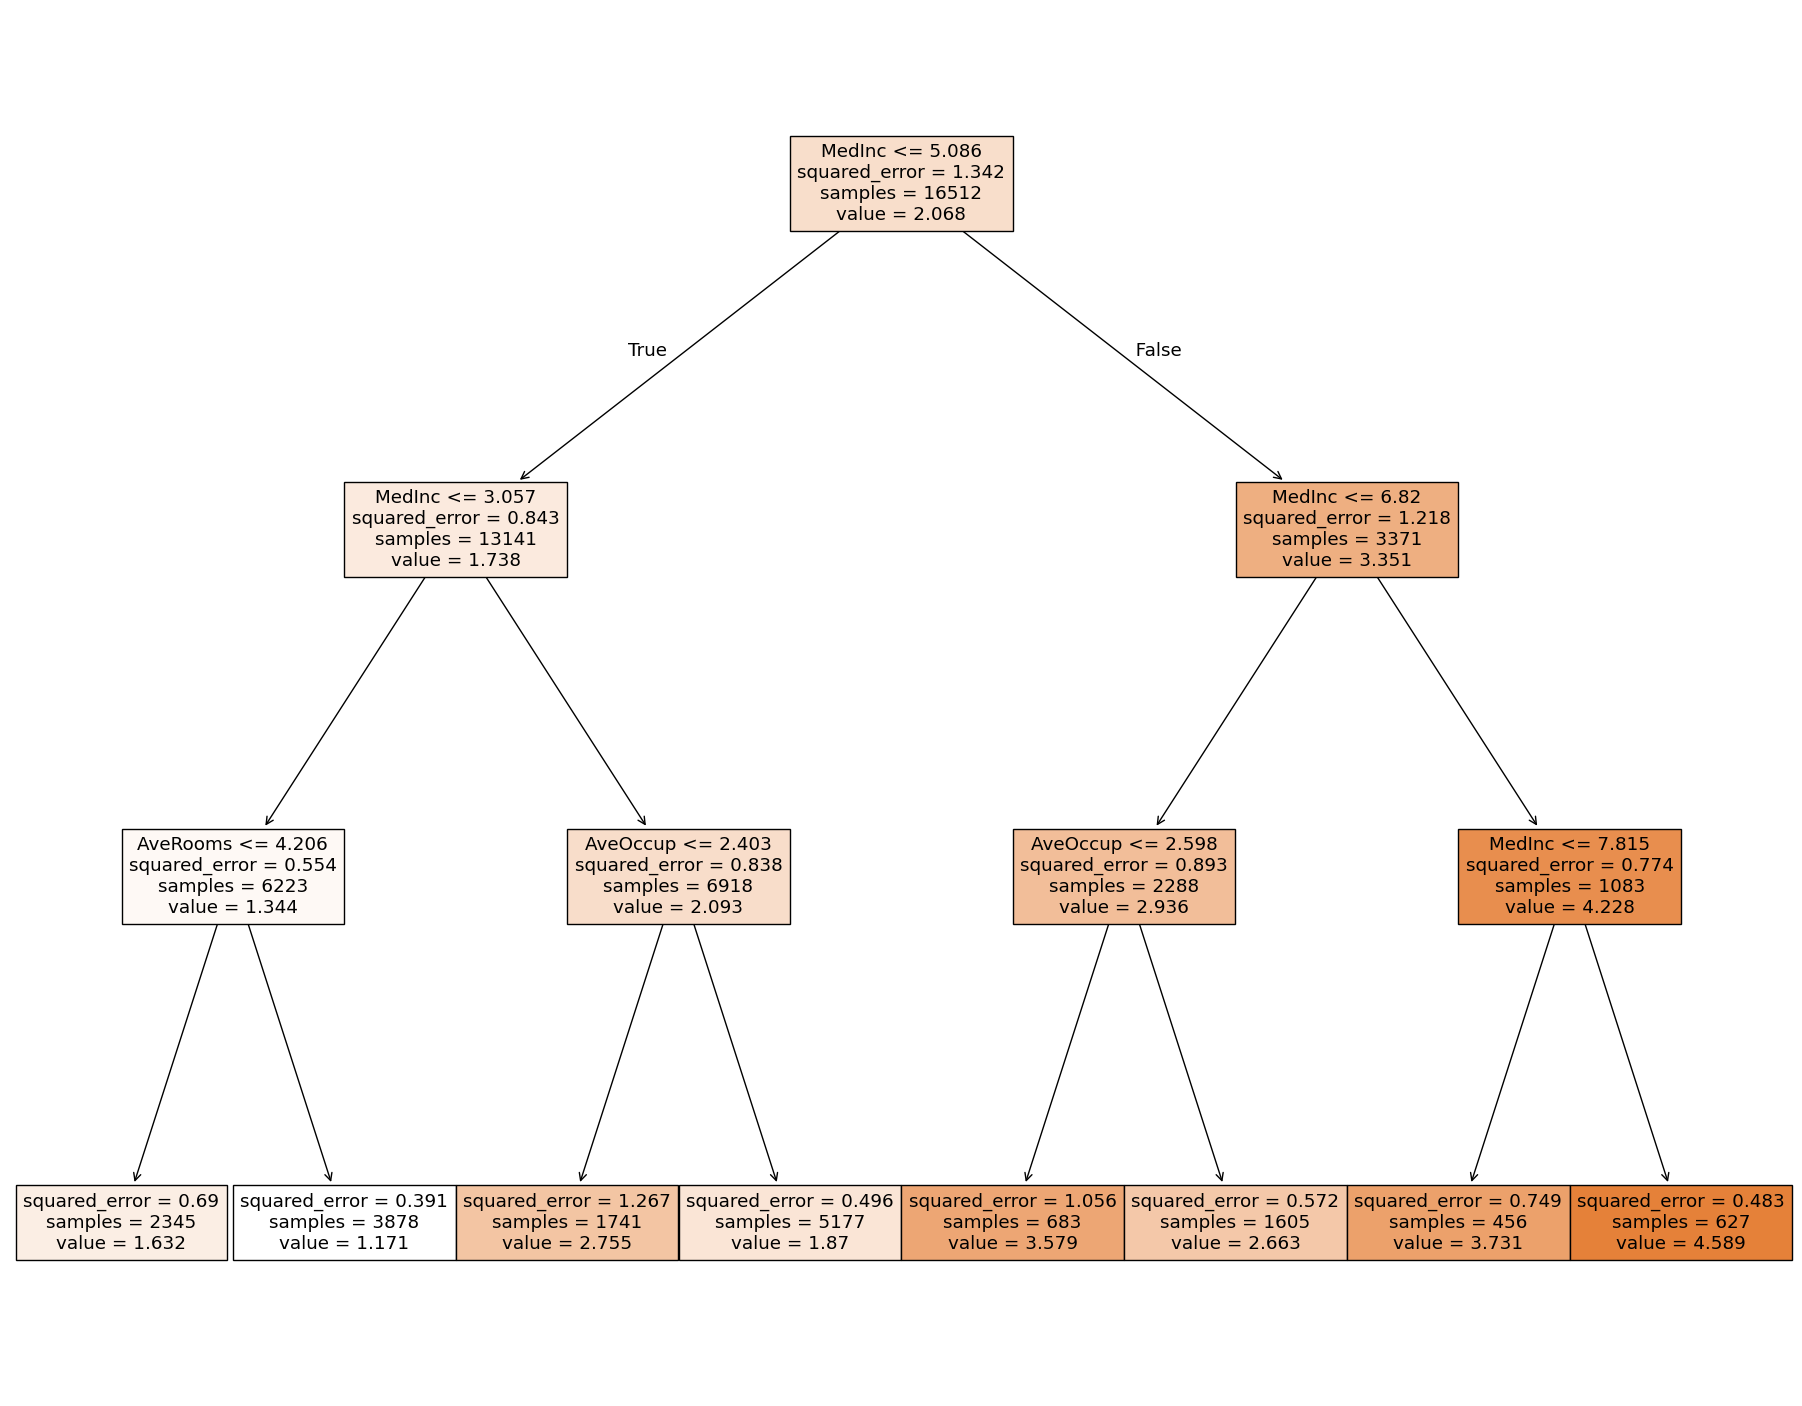

In [ ]:
tree_plot = DecisionTreeRegressor(max_depth=3, min_samples_leaf=3).fit(x_train, y_train)
plt.figure(figsize=(23,18))
tree.plot_tree(tree_plot, feature_names=x_train.columns, filled=True)
plt.show()

In [ ]:
text_presentation = tree.export_text(tree_plot)
print(text_presentation)

|--- feature_0 <= 5.09
|   |--- feature_0 <= 3.06
|   |   |--- feature_2 <= 4.21
|   |   |   |--- value: [1.63]
|   |   |--- feature_2 >  4.21
|   |   |   |--- value: [1.17]
|   |--- feature_0 >  3.06
|   |   |--- feature_5 <= 2.40
|   |   |   |--- value: [2.76]
|   |   |--- feature_5 >  2.40
|   |   |   |--- value: [1.87]
|--- feature_0 >  5.09
|   |--- feature_0 <= 6.82
|   |   |--- feature_5 <= 2.60
|   |   |   |--- value: [3.58]
|   |   |--- feature_5 >  2.60
|   |   |   |--- value: [2.66]
|   |--- feature_0 >  6.82
|   |   |--- feature_0 <= 7.82
|   |   |   |--- value: [3.73]
|   |   |--- feature_0 >  7.82
|   |   |   |--- value: [4.59]



In [ ]:
trees2 = DecisionTreeRegressor(max_depth=9, random_state=7)
trees2.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=9, random_state=7)

In [ ]:
trees2.score(x_train, y_train), trees2.score(x_test, y_test)
# результат получше, увеличена глубина, но есть переобучение

(0.8016579320320305, 0.6954817499924646)

In [ ]:
trees3 = DecisionTreeRegressor(max_depth=9, min_samples_leaf=4, random_state=7)
trees3.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=9, min_samples_leaf=4, random_state=7)

In [ ]:
trees3.score(x_train, y_train), trees3.score(x_test, y_test)
# фиксированное количество объектов в листе убрало переобучение, но качестов не плохое

(0.795512173792027, 0.7031644530785351)

In [ ]:
trees4 = DecisionTreeRegressor(max_depth=12, min_samples_leaf=5, random_state=5678)
trees4.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=12, min_samples_leaf=5, random_state=5678)

In [ ]:
trees4.score(x_train, y_train), trees4.score(x_test, y_test)
# результат совсем на чуть-чуть лучше, но увеличилось переобучение

(0.8716489171429276, 0.7104854992162135)